#### Step 1: Load the Data

In [4]:
train_df = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv')


#### Step 2: Preprocess the Data

In [7]:
# Extract the features and labels from the DataFrame (train)
x_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

# Reshape and normalize the images (train)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0

# Extract the features and labels from the DataFrame (test)
x_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

# Reshape and normalize the images (test)
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

#### Step 3: Create the Input Pipeline

Read the data: We load it from our files.

Batch the data: We send it in small groups of 32.

Shuffle the data: We mix it up so it’s not in order.

In [8]:
# Step 3: Create the Input Pipeline
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32).shuffle(buffer_size=1000)


2026-06-05 06:01:55.023960: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


#### Step 4: Define the Model

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Step 5: Compile the Model

In [12]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


#### Step 6: Train the Model

In [13]:
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9277 - loss: 0.2584 - val_accuracy: 0.9616 - val_loss: 0.1371
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9664 - loss: 0.1141 - val_accuracy: 0.9674 - val_loss: 0.1097
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9775 - loss: 0.0778 - val_accuracy: 0.9740 - val_loss: 0.0856
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9824 - loss: 0.0578 - val_accuracy: 0.9730 - val_loss: 0.0893
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9861 - loss: 0.0449 - val_accuracy: 0.9750 - val_loss: 0.0806


#### Step 7: Evaluate the Model

In [14]:
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=2)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
train_acc,test_acc

1875/1875 - 4s - 2ms/step - accuracy: 0.9897 - loss: 0.0337
313/313 - 1s - 2ms/step - accuracy: 0.9750 - loss: 0.0806


(0.989716649055481, 0.9750000238418579)

##### Optimize tensorflow pipeline
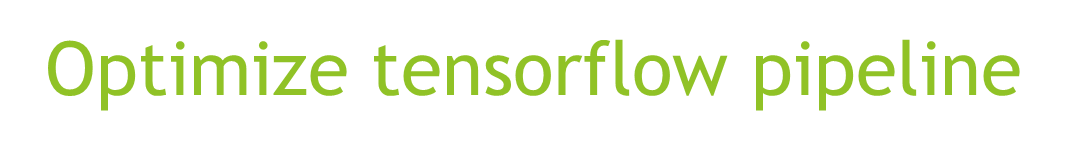
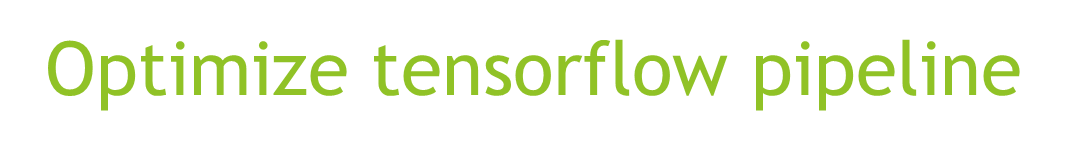
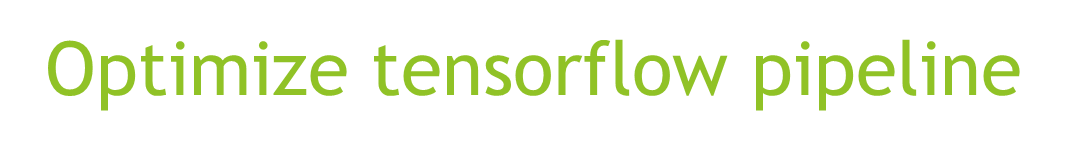
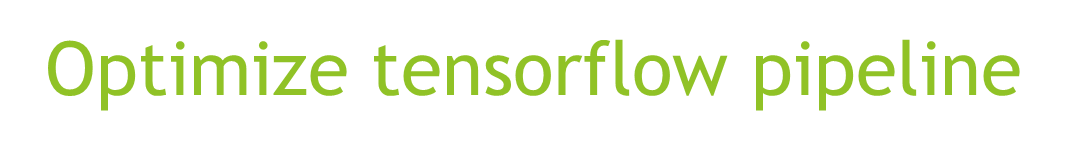

#### Step 1: Cache the Dataset

In [ ]:
# dataset = dataset.cache()  # This will cache the dataset in memory after the first load


#### Step 2: Prefetch the Data

In [ ]:
#dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE) 
# This will allow later elements to be prepared while the model is training on current elements
